# Statistics for Michel electron candidate (cosmic 28116)

### Created by Shu, 20250920---

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


coinNum = [] # wvf coin num--

file_list = [
    "./pdsStat_20250920/print_wvfCoin_count20250920.txt"
]
for fname in file_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = int(parts[1].strip())
                        coinNum.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")






print("Track candidates (TPC cut)  : 12707")
print("Track candidates with NO wvf: 1335")
print("Number of track candidates  :", len(coinNum))





Track candidates (TPC cut)  : 12707
Track candidates with NO wvf: 1335
Number of track candidates  : 12127



Candidates with #opWvf>=4:  8284 / 12127 (68.31%)


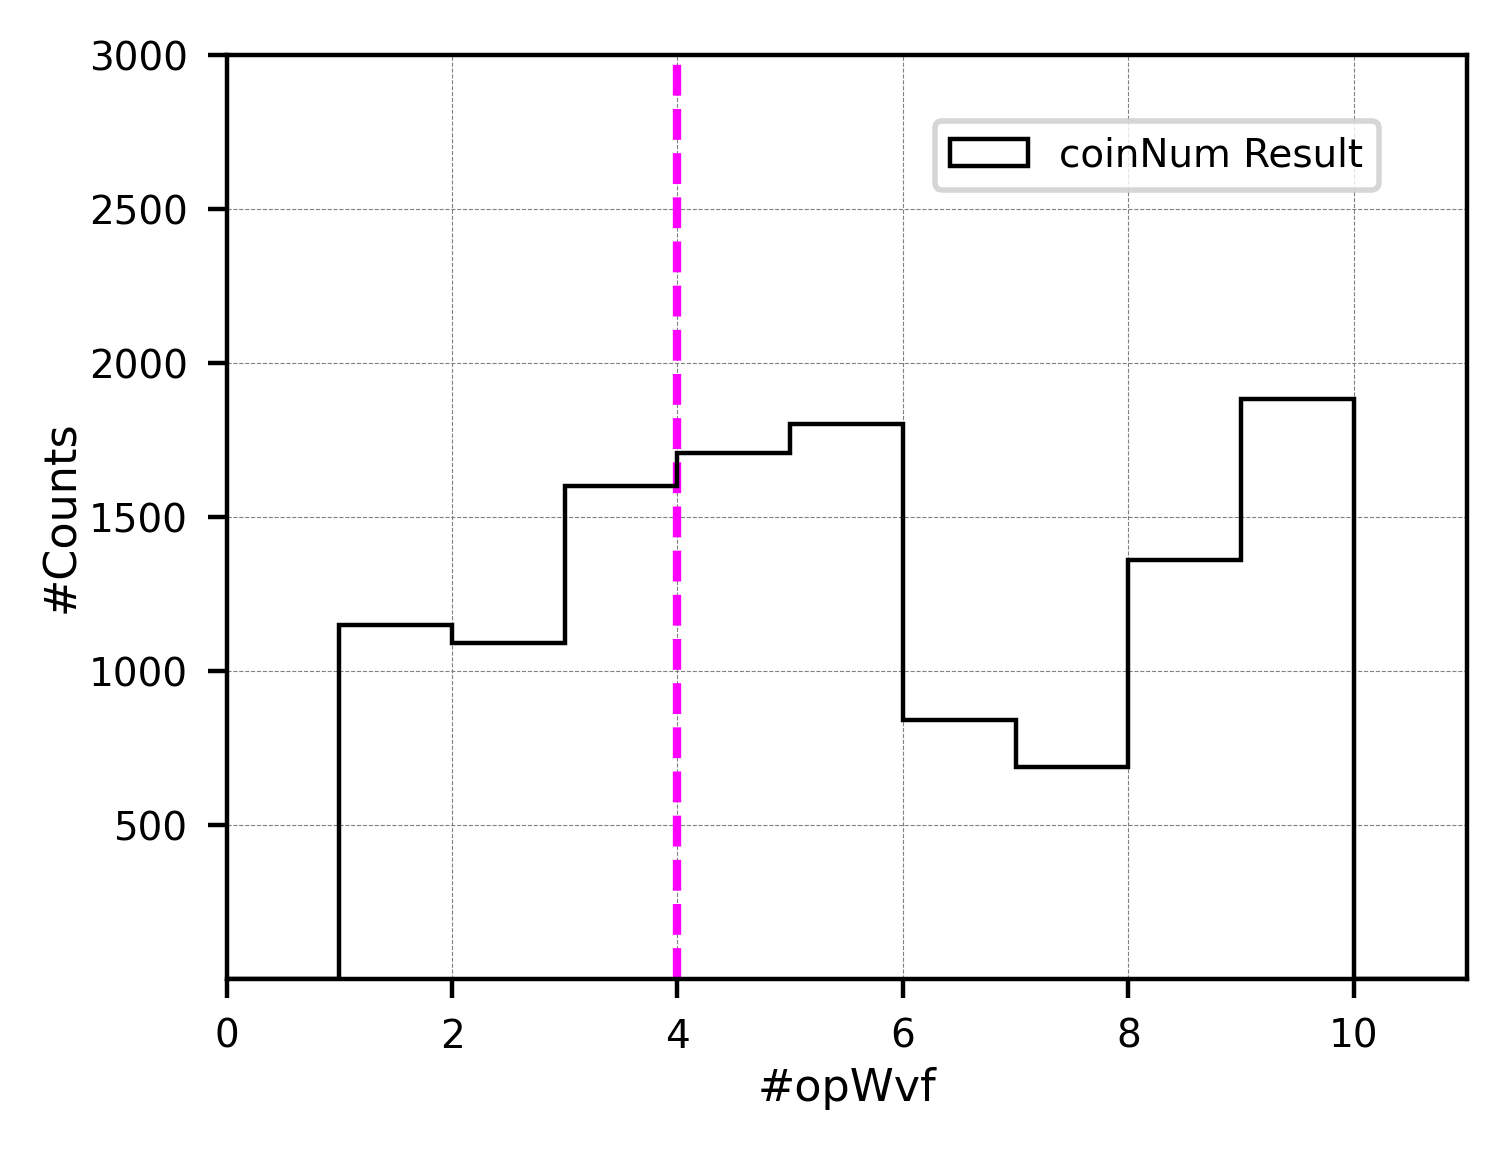

In [10]:


#Apply preliminary cut #opWvf >=4:=====================
coinNum_cut4 = []
coinNum_trueE_cut4 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]

    if coin >=4:
        coinNum_cut4.append(coin)

print("\nCandidates with #opWvf>=4: ", len(coinNum_cut4), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut4)/len(coinNum)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([4, 4], [0, 3000], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')

plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 3000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 4)

In [9]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    ms: Optional[float] = None #Michel score---
    mh: Optional[int] = None #Michel hits---



def read_colon_files(files, cast_type=float):
    """Read one or more colon-formatted files ('key: value') and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) >= 2:
                        try:
                            values.append(cast_type(parts[1].strip()))
                        except ValueError:
                            print(f"Could not convert {parts[1].strip()} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values


def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values



dates = ["20250920"]

muon_time = read_colon_files([f"./pdsStat_20250920/muon_time_{d}.txt" for d in dates], cast_type=int)
michel_time = read_colon_files([f"./pdsStat_20250920/michel_time_{d}.txt" for d in dates], cast_type=int)
muon_intensity = read_colon_files([f"./pdsStat_20250920/muon_intensity_{d}.txt" for d in dates])
michel_intensity = read_colon_files([f"./pdsStat_20250920/michel_intensity_{d}.txt" for d in dates])

posX = read_plain_files([f"./pdsStat_20250920/posX_extract_{d}.txt" for d in dates])
posY = read_plain_files([f"./pdsStat_20250920/posY_extract_{d}.txt" for d in dates])
posZ = read_plain_files([f"./pdsStat_20250920/posZ_extract_{d}.txt" for d in dates])

ms = read_plain_files([f"./pdsStat_20250920/score_extract_{d}.txt" for d in dates])
mh = read_plain_files([f"./pdsStat_20250920/hits_extract_{d}.txt" for d in dates], cast_type=int)


print("Single list check:---------------------------------------")
print("muon_time (TPC cut)       :", len(muon_time))
print("michel_time (TPC cut)     :", len(michel_time))
print("muon_intensity (TPC cut)  :", len(muon_intensity))
print("michel_intensity (TPC cut):", len(michel_intensity))
print("posX (TPC cut)            :", len(posX))
print("posY (TPC cut)            :", len(posY))
print("posZ (TPC cut)            :", len(posZ))
print("michel score (TPC cut)    :", len(ms))
print("michel hits (TPC cut)     :", len(mh))

print("\nMin[muon_intensity]       : ", np.min(muon_intensity))
print("Min[michel_intensity]     : ", np.min(michel_intensity))
print("Min[michel_time]          : ", np.min(michel_time))




#Very initial dataset------------------------------------
events_veryInitial = []
n_events = min(len(muon_time), len(michel_time), len(muon_intensity),
               len(michel_intensity), len(posX), len(posY), len(posZ),
               len(ms), len(mh))

for i in range(n_events):
    ev = PdsEvent(
        muon_time=muon_time[i],
        michel_time=michel_time[i],
        muon_intensity=muon_intensity[i],
        michel_intensity=michel_intensity[i],
        posX=posX[i],
        posY=posY[i],
        posZ=posZ[i],
        ms=ms[i],
        mh=mh[i]
    )
    events_veryInitial.append(ev)

print("\nVery initial dataset: ", len(events_veryInitial))





#Apply cuts on peak intensities-----------------------------
events_reco_initial = []
events_true_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity

    if muIntensity > 0.7 and miIntensity > -0.0:
        events_reco_initial.append(ev)

print("\nDataset after initial intensity-cut----------------------")
print("#events: ", len(events_reco_initial)) 







Single list check:---------------------------------------
muon_time (TPC cut)       : 8284
michel_time (TPC cut)     : 8284
muon_intensity (TPC cut)  : 8284
michel_intensity (TPC cut): 8284
posX (TPC cut)            : 8284
posY (TPC cut)            : 8284
posZ (TPC cut)            : 8284
michel score (TPC cut)    : 8284
michel hits (TPC cut)     : 8284

Min[muon_intensity]       :  0.462122
Min[michel_intensity]     :  0.0
Min[michel_time]          :  0

Very initial dataset:  8284

Dataset after initial intensity-cut----------------------
#events:  7306



Decay points distribution: 
# of X < 0 :  4844 (66.30%)
# of X >= 0:  2462 (33.70%)


<Figure size 1600x1200 with 0 Axes>

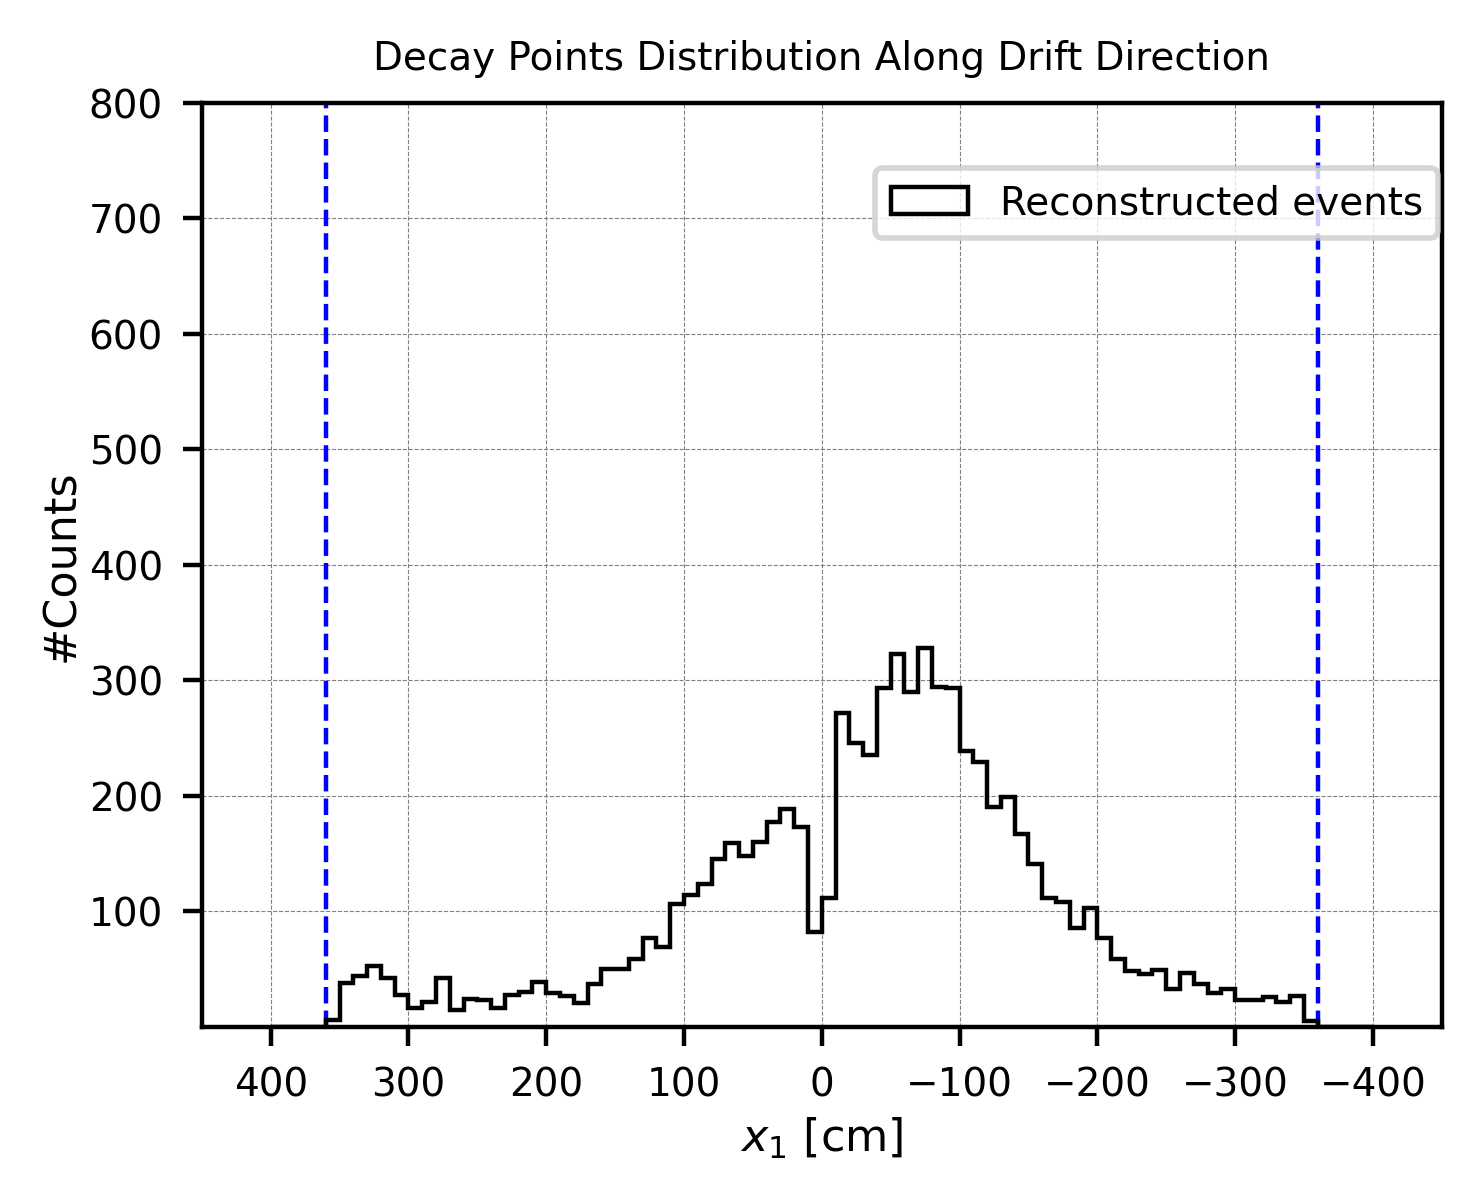

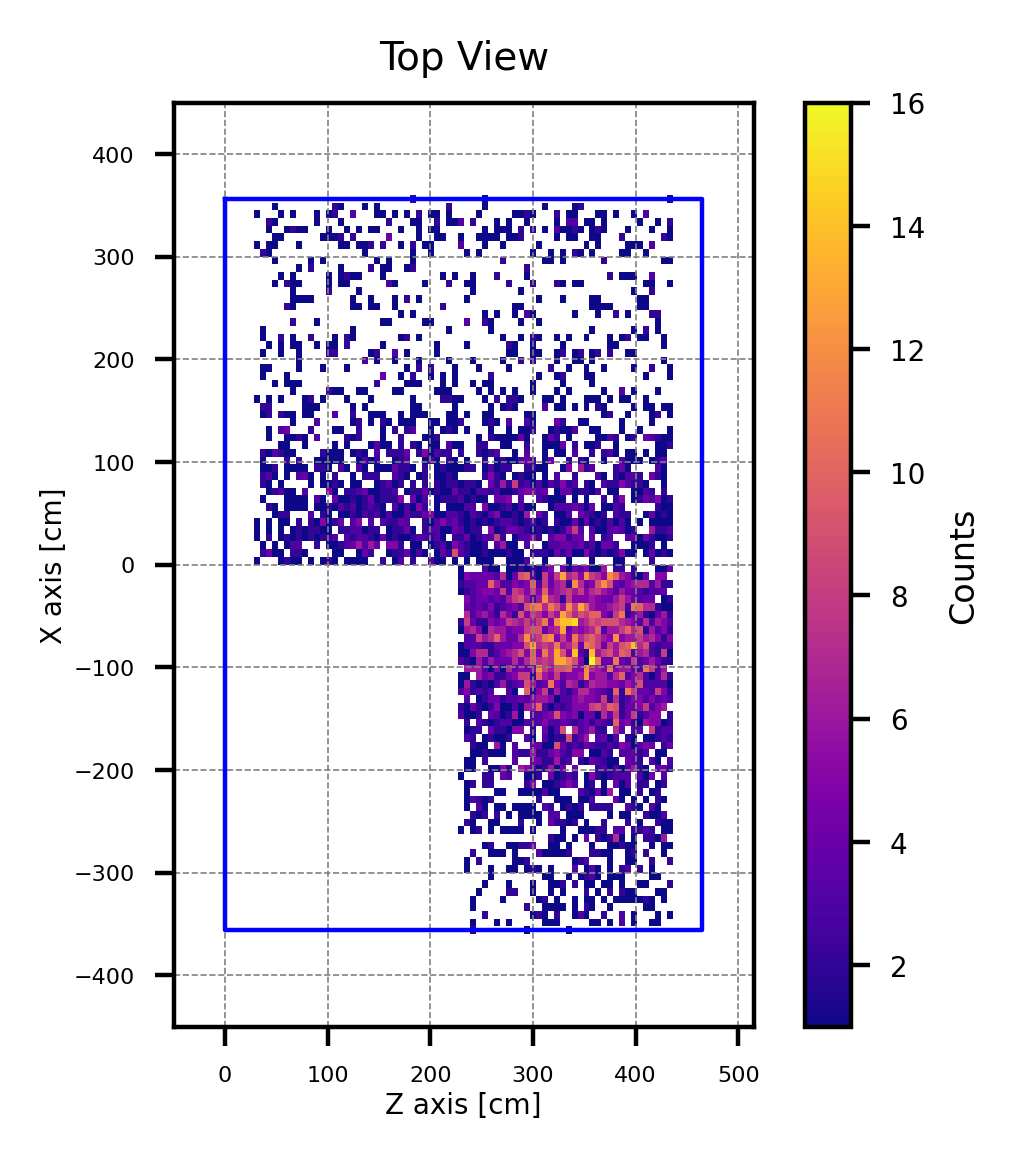

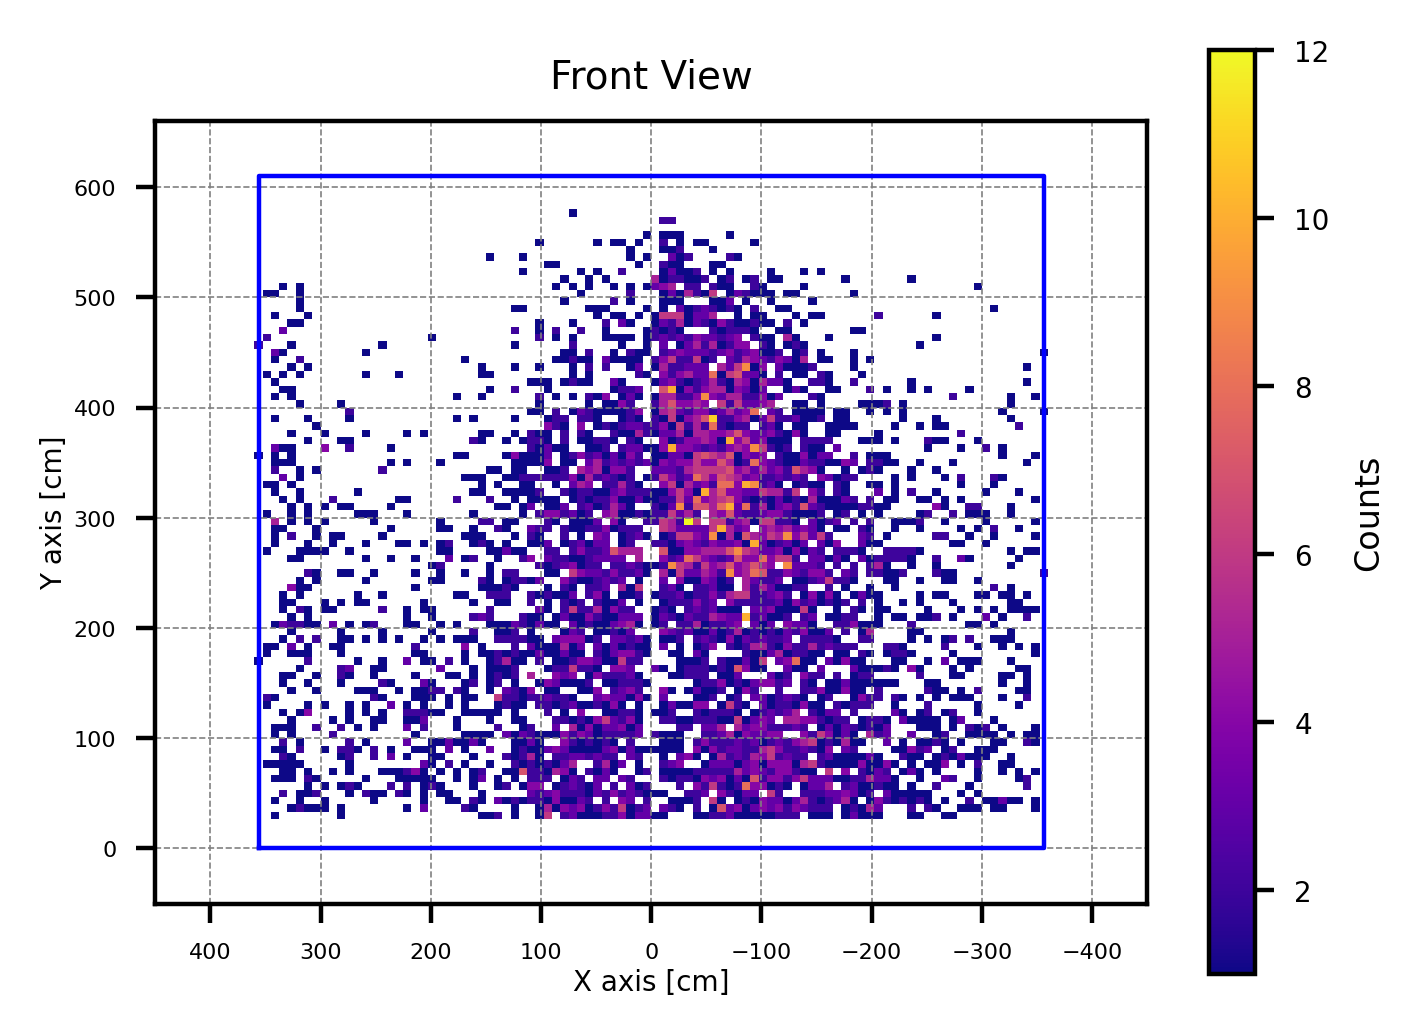

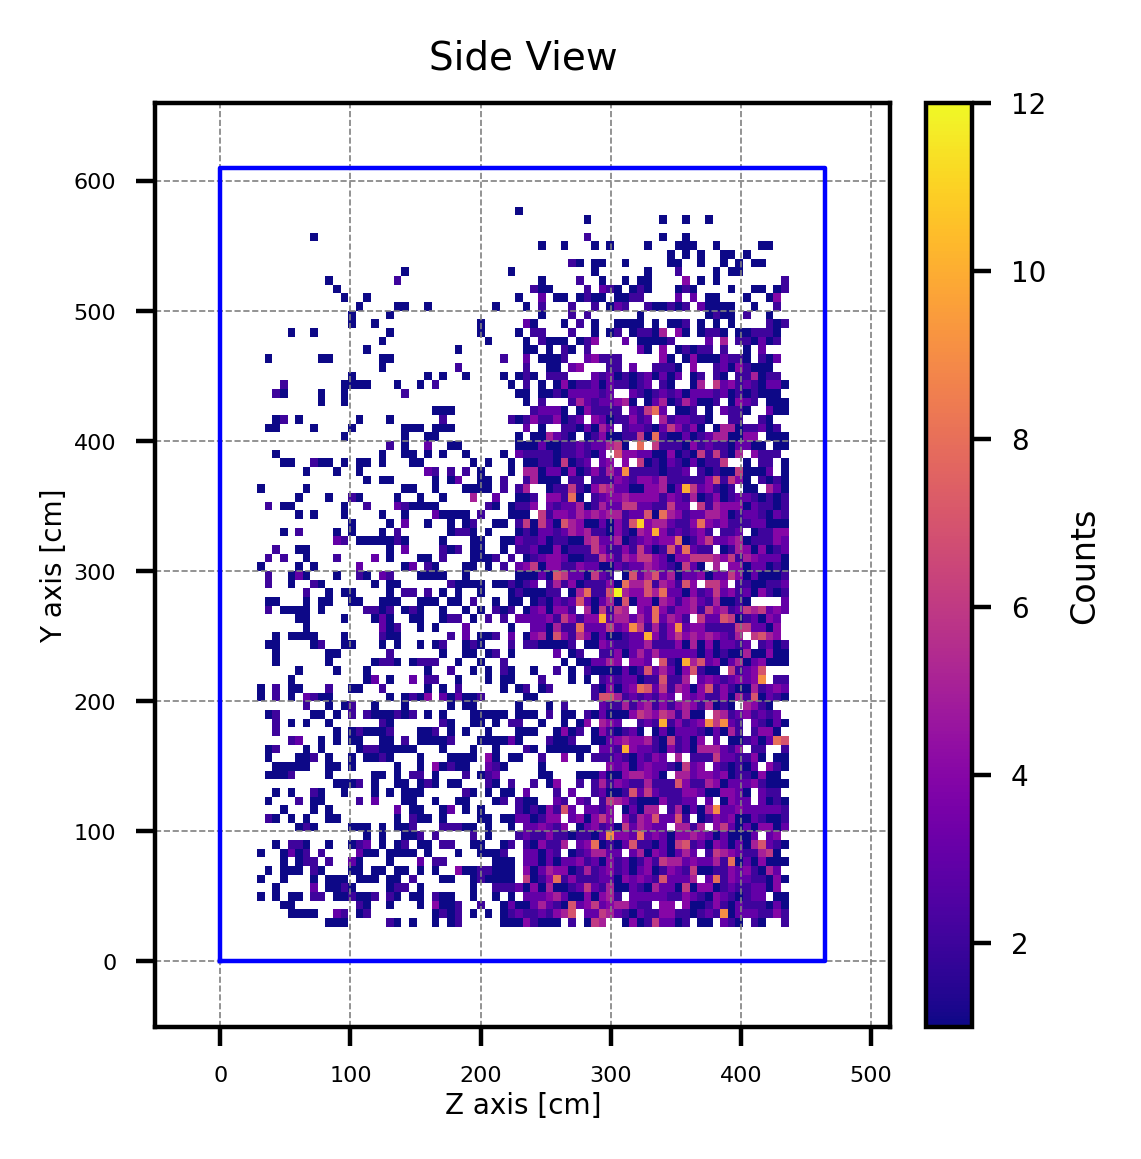

In [10]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(posX)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco_initial if ev.posX < 0])
num_posX = len([ev for ev in events_reco_initial if ev.posX > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco_initial)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco_initial)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 800], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 800], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(posX, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 800)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posY, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 



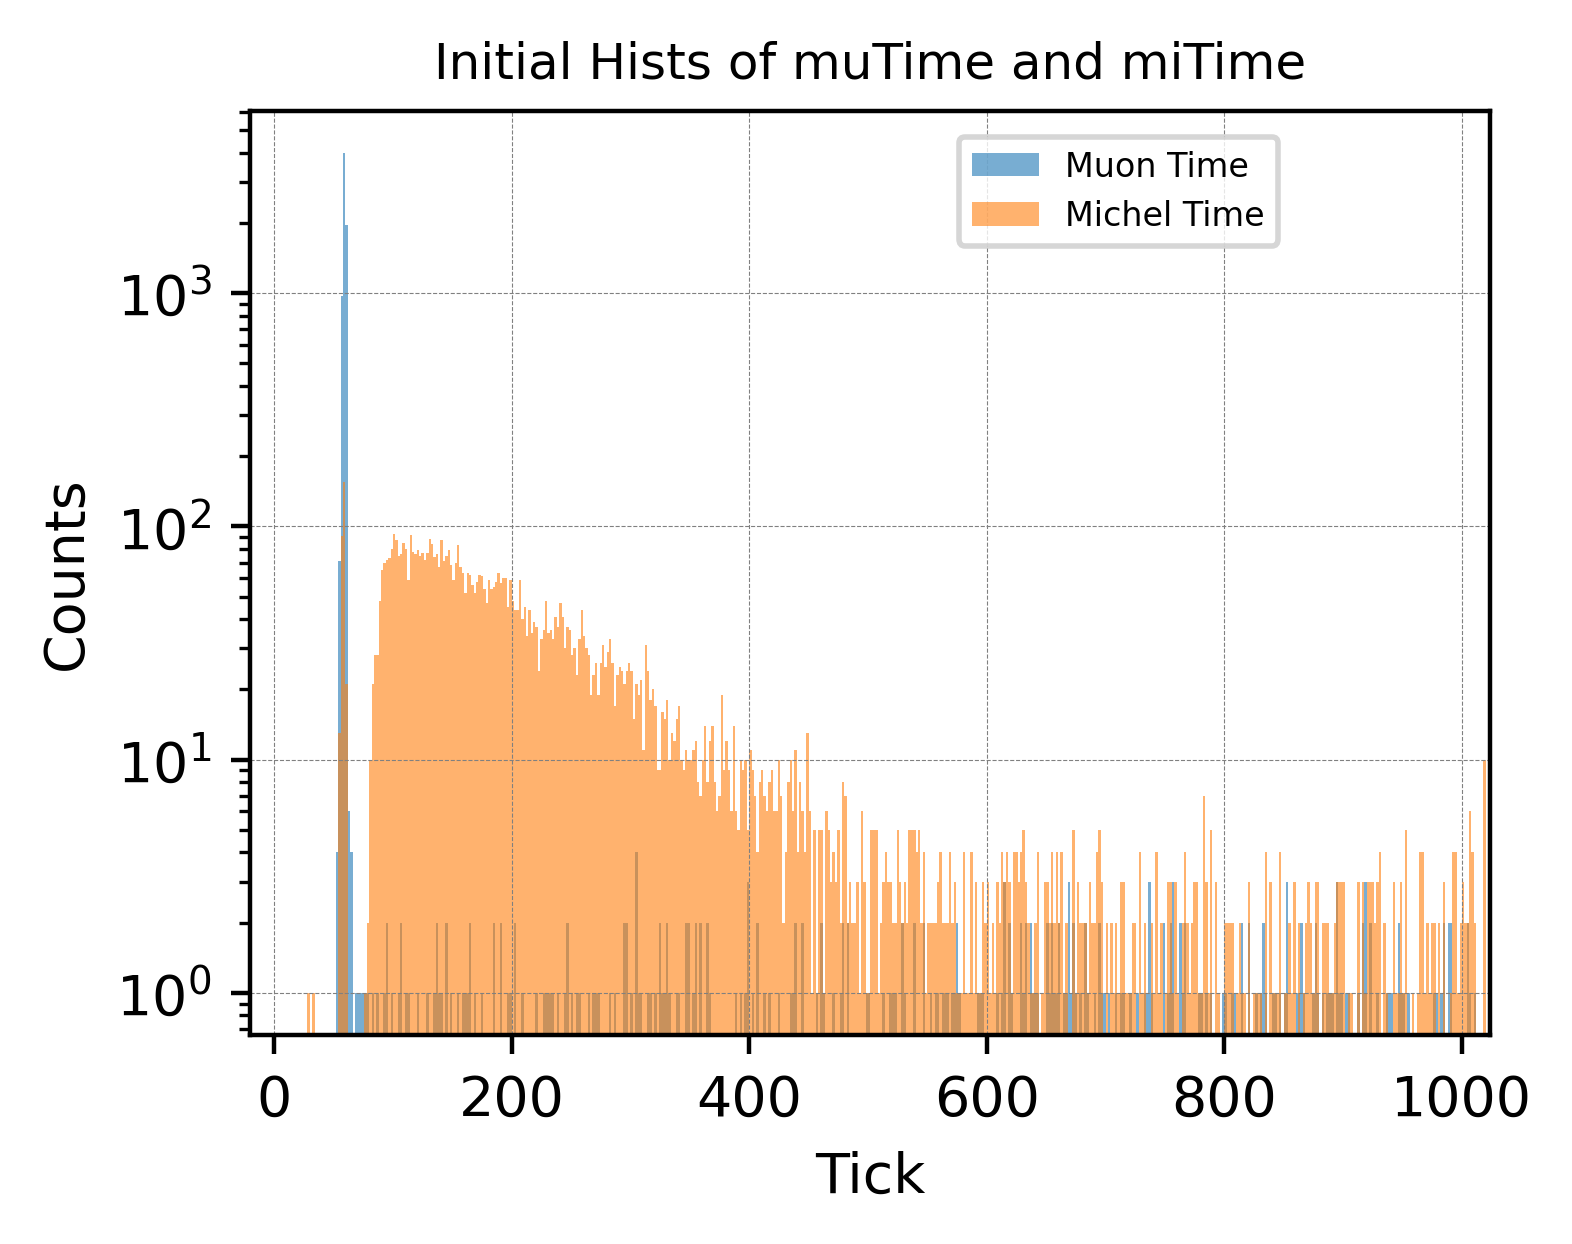

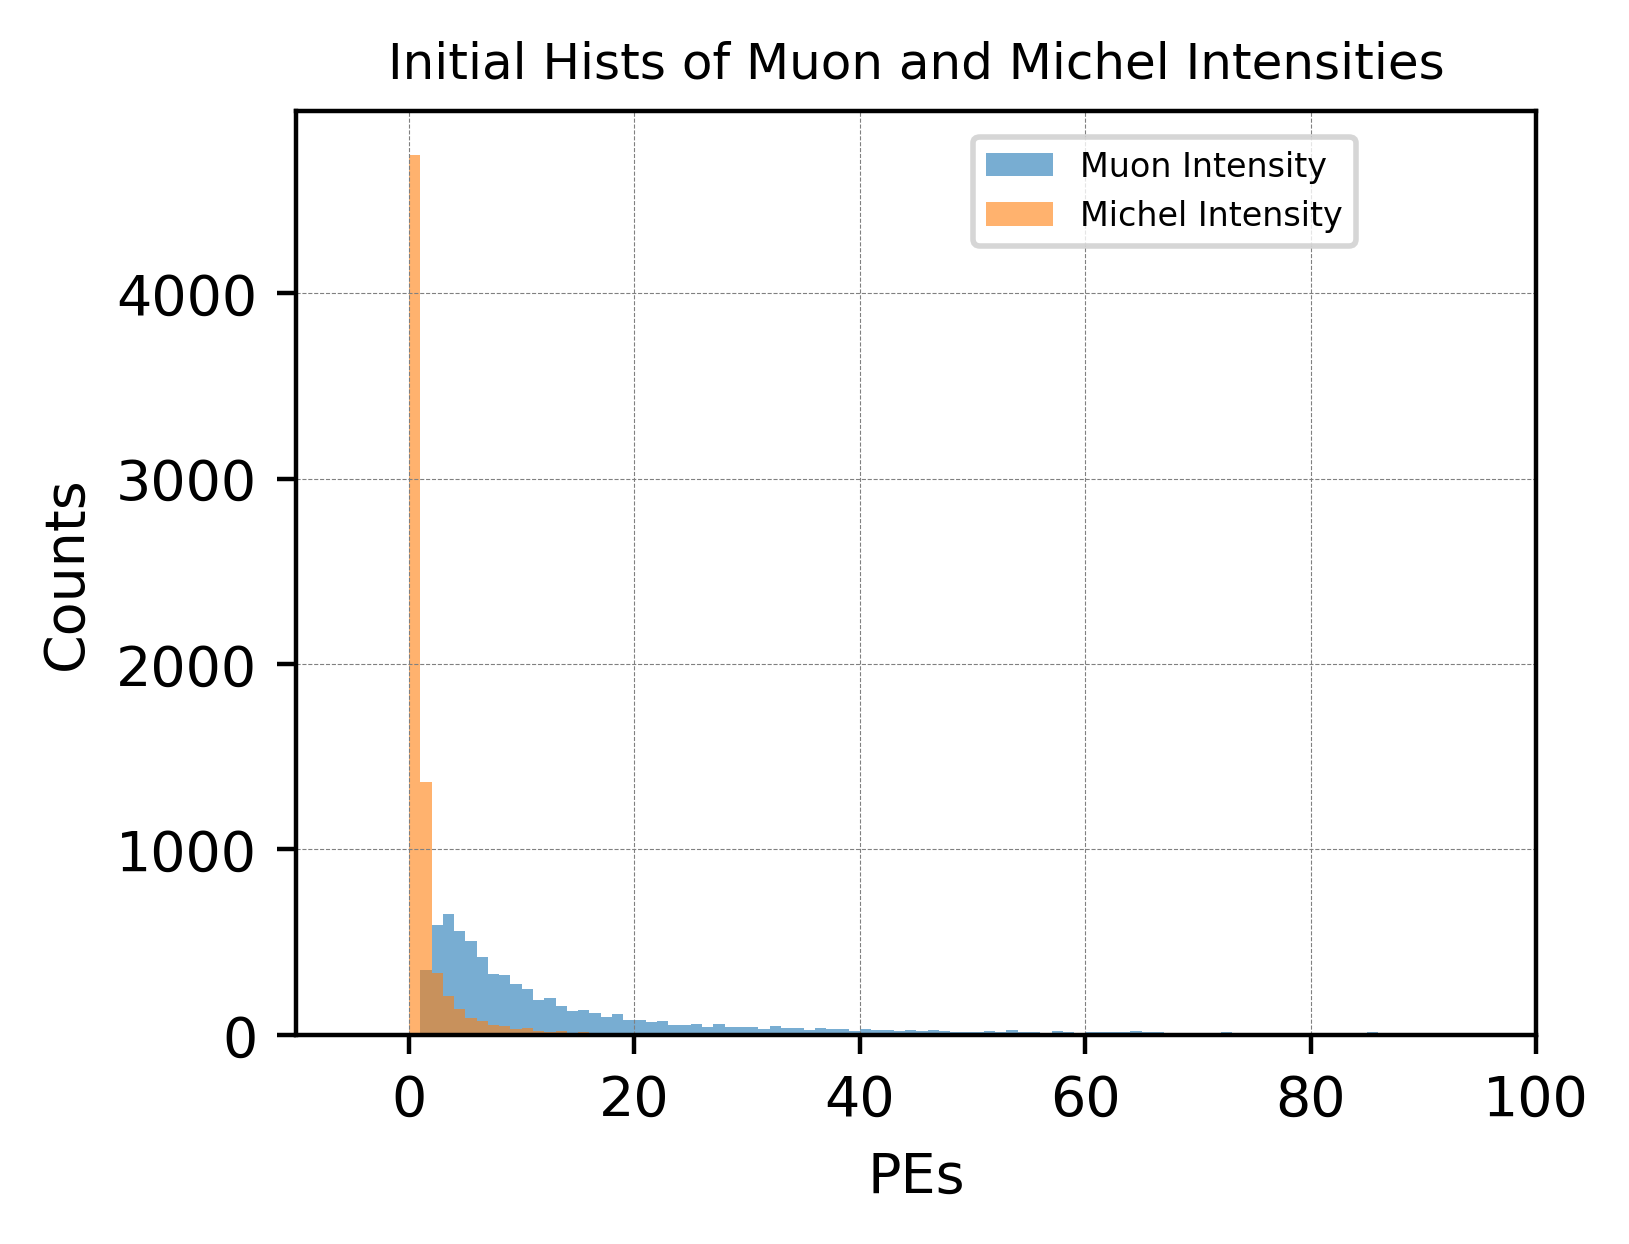

In [12]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]



#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = -10
range_max_initial = 1024
bin_width_initial = 2  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)#[-20, 1024]
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals (constrain muTime to [50, 65])

Muon events selection (mu peak constrained to [120, 130]):
Updated Muon events:  7009 (95.93%)
Length of time_difference (Updated):  7009


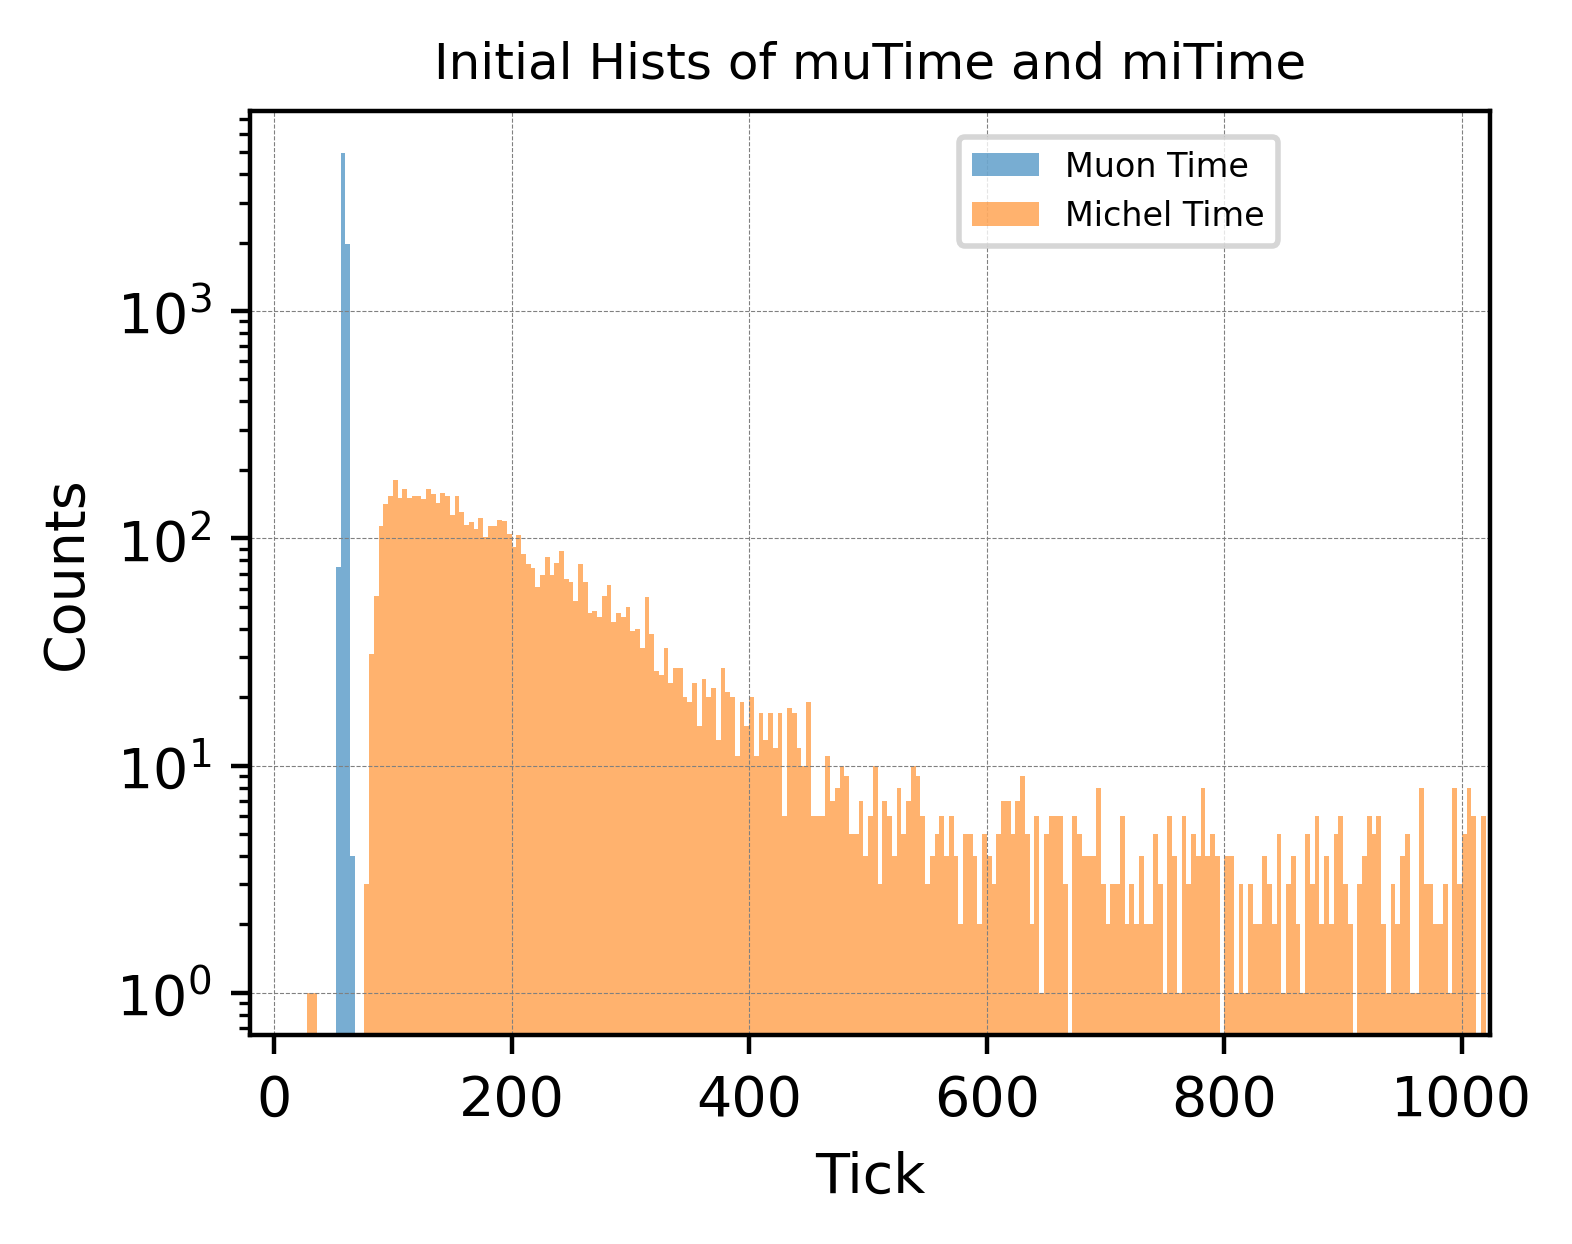




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  7009


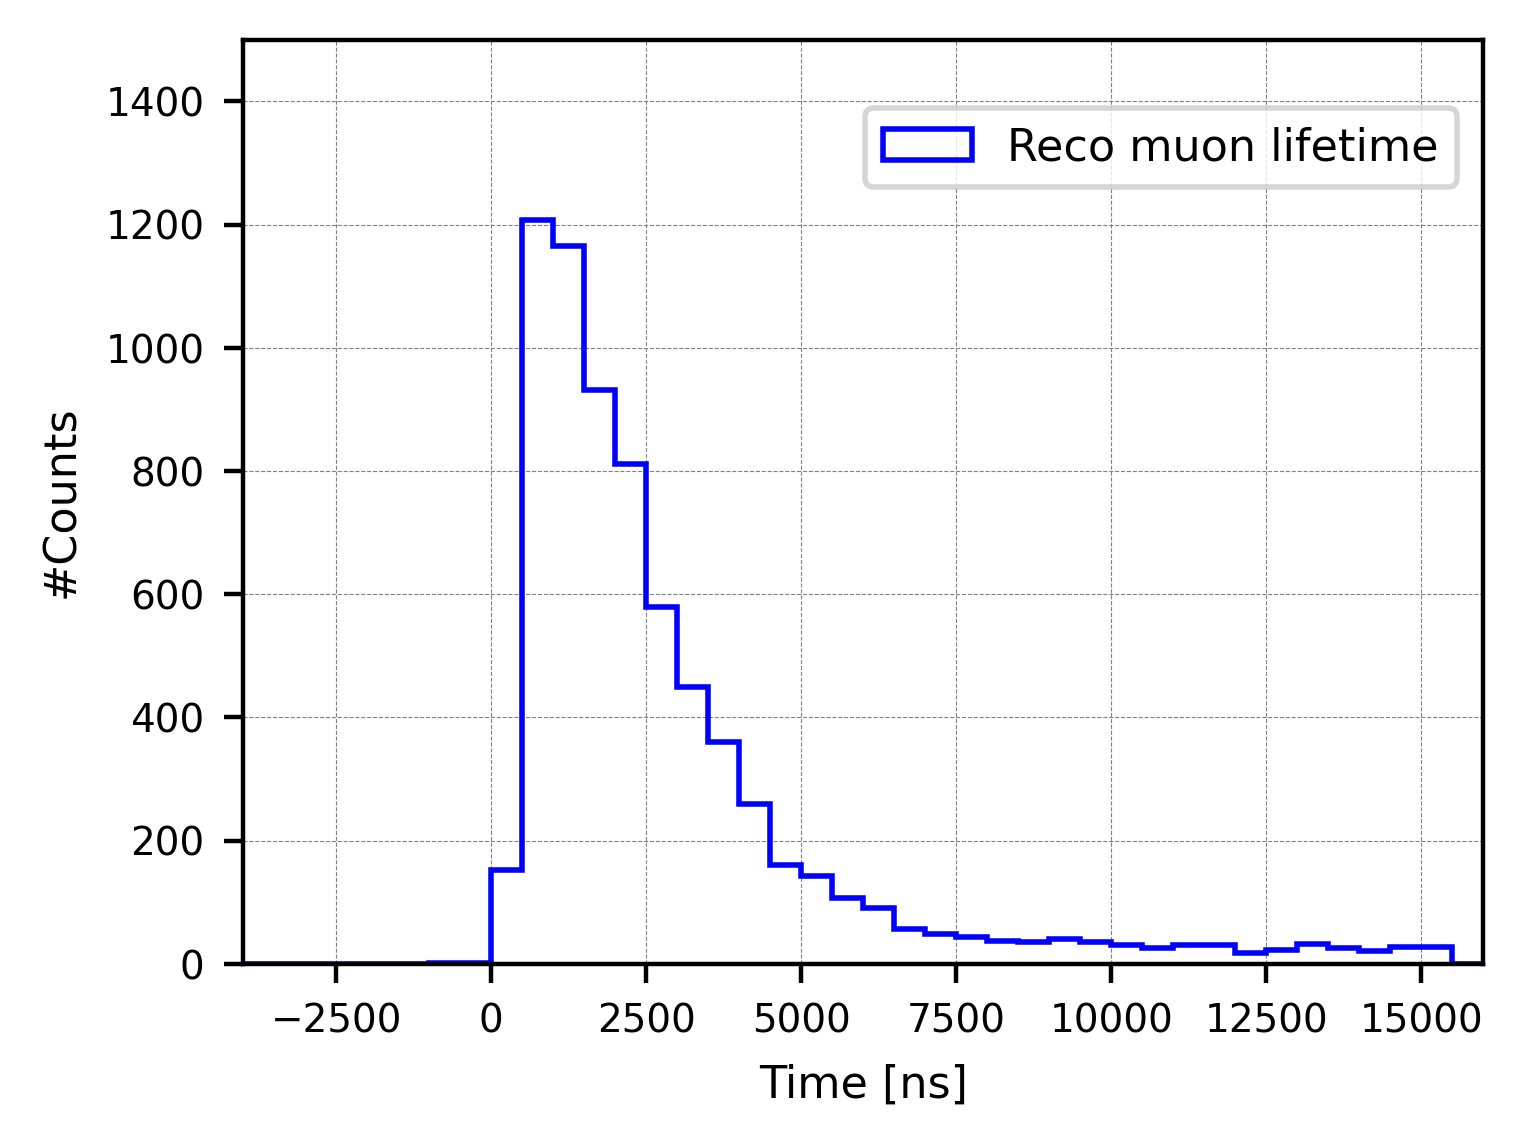

In [13]:
events_reco_update1 = []
lifetime_reco_update1 = []

for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time
    miIntensity = ev.michel_intensity

    if 50 <= muTime <= 65 and miIntensity > 0.1:#Also remove unphysical michel events---
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)


print("Muon events selection (mu peak constrained to [120, 130]):")
print("Updated Muon events: ", len(events_reco_update1),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))










#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---


print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')


plt.xlim(-4000, 16000)
plt.ylim(0, 1500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification 2: remove events with unphysical lifetime (constrain lifetime to [500, inf))




Lifetime distribution (Updated):
# Updated Candidates [500, 16000]:  6854


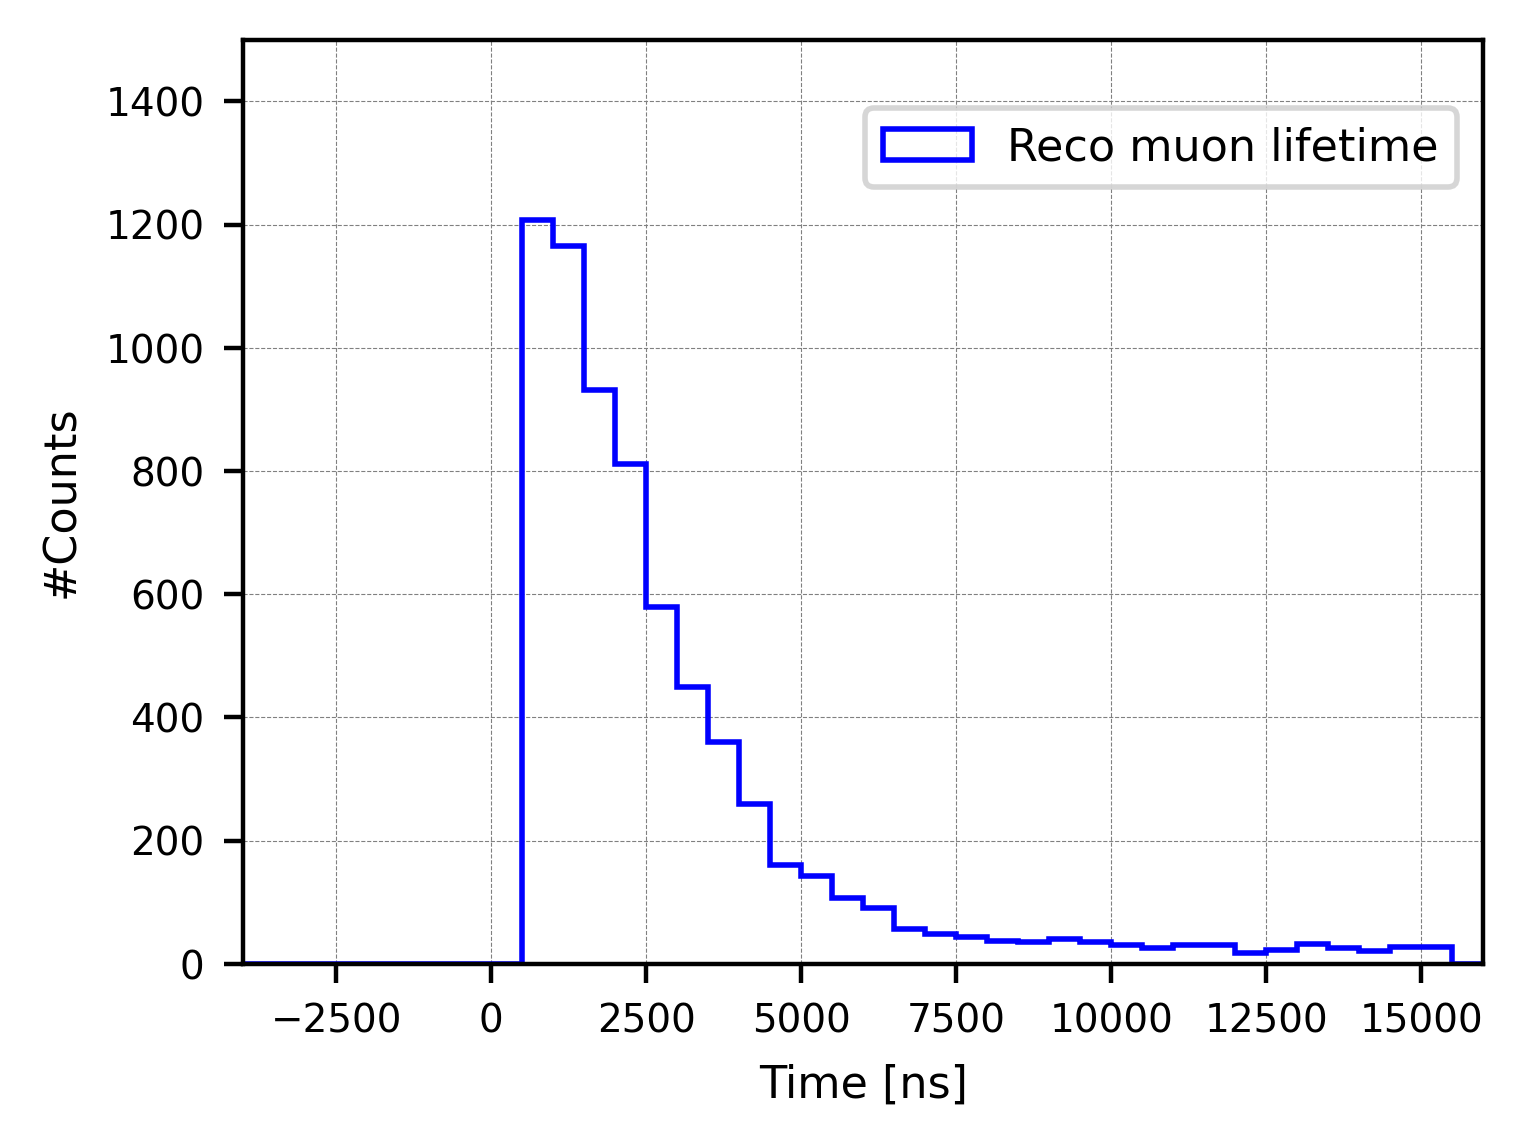

In [14]:
events_reco_update2 = []#Dataset after Purification 2---
events_true_update2 = []
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    if 500 <= timeDiff:
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [500, 16000]: ", len(events_reco_update2))






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(-4000, 16000)
plt.ylim(0, 1500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






### Lifetime fittings:

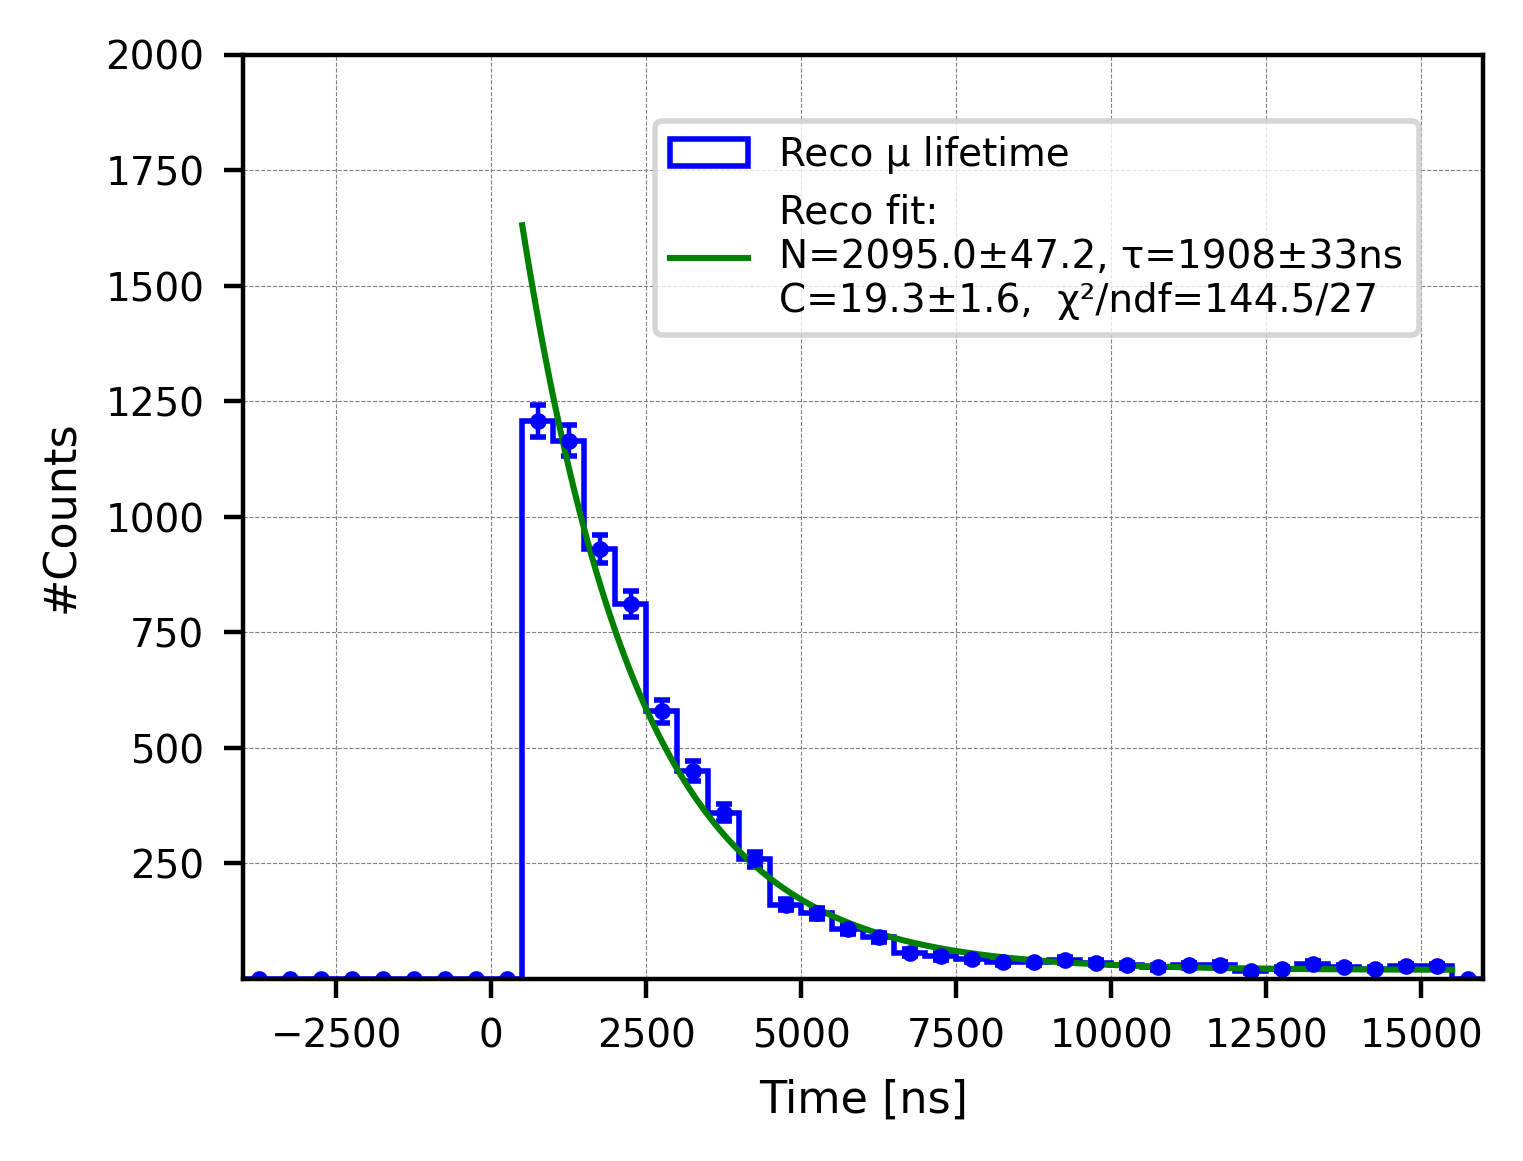

In [15]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt



#======Single Fitting==================================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histograms (Reco + True, but error bars only for Reco)
counts_reco, bin_edges_reco, _ = plt.hist(
    lifetime_reco_update2, bins=bins, range=(range_min, range_max),
    edgecolor='blue', histtype='step', linewidth=1.0,
    label='Reco μ lifetime'
)

# Add error bars for Reco
bin_centers_reco = 0.5 * (bin_edges_reco[:-1] + bin_edges_reco[1:])
errors_reco = np.sqrt(np.clip(counts_reco, 0, None))
plt.errorbar(
    bin_centers_reco, counts_reco, yerr=errors_reco,
    fmt='o', color='blue', markersize=2.0, elinewidth=0.8, capsize=1.5,
    label=None  # don’t duplicate legend entry
)


# ---------- add χ² fits with constant background ----------
def exp1C(t, N, tau, C):
    return N * np.exp(-t / tau) + C

def fit_and_overlay(sample, label, fit_min, fit_max, color=None, line_width=1.2, line_style='-'):
    # Use the SAME binning
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fit window
    m = (centers >= fit_min) & (centers <= fit_max)
    x = centers[m]
    y = counts[m].astype(float)

    if len(x) < 3 or y.sum() <= 0:
        print(f"[WARN] Not enough stats to fit {label}")
        return

    # Uncertainty per bin
    sigma = np.sqrt(np.clip(y, 1.0, None))

    # Initial guesses
    N0 = float(y.max())
    tau0 = max(100.0, (np.sum(y * (x - fit_min)) / max(np.sum(y), 1.0)))  # ns
    C0 = min(y)  # background level ~ lowest bin

    # Weighted least squares (χ²)
    popt, pcov = curve_fit(exp1C, x, y, p0=[N0, tau0, C0],
                           sigma=sigma, absolute_sigma=True, maxfev=20000)
    N_fit, tau_fit, C_fit = popt
    N_err, tau_err, C_err = np.sqrt(np.diag(pcov))

    # χ²/ndf
    yfit = exp1C(x, *popt)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf = max(len(x) - len(popt), 1)

    # Overlay smooth curve
    t_smooth = np.linspace(fit_min, fit_max, 400)
    plt.plot(
        t_smooth,
        exp1C(t_smooth, *popt),
        linewidth=line_width,
        linestyle=line_style,
        color=color,
        label=(
            f"{label} fit:\n"
            f"N={N_fit:.1f}±{N_err:.1f}, τ={tau_fit:.0f}±{tau_err:.0f}ns\n"
            f"C={C_fit:.1f}±{C_err:.1f},  χ²/ndf={chi2:.1f}/{ndf}"
        ),
    )


# Fit windows
fit_and_overlay(lifetime_reco_update2, "Reco",  500, 15500, color="green", line_width=1.1, line_style='-')

plt.xlim(-4000, 16000)
plt.ylim(0.1, 2000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=9,
           markerscale=5, ncol=1, prop={'size':7})
plt.show()


<br />
<br />
<br />
<br />

## Explore Final Dataset (After purification 2):

In [226]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    reco_lifetime: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))

#New calculated reco & true lifetime lists:
recoLife_update2 = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)
 

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life in zip(
    events_reco_update2, 
    recoLife_update2
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        reco_lifetime=reco_life
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))


Size of events_reco_update2 (previous class):  687
Size of lifetime_reco_update2               :  687

Length of final dataset in format of new class:  687


### Space Distribution:


Decay points distribution: 

# of X < 0 :  357 (51.965%)
# of X >= 0:  330 (48.035%)


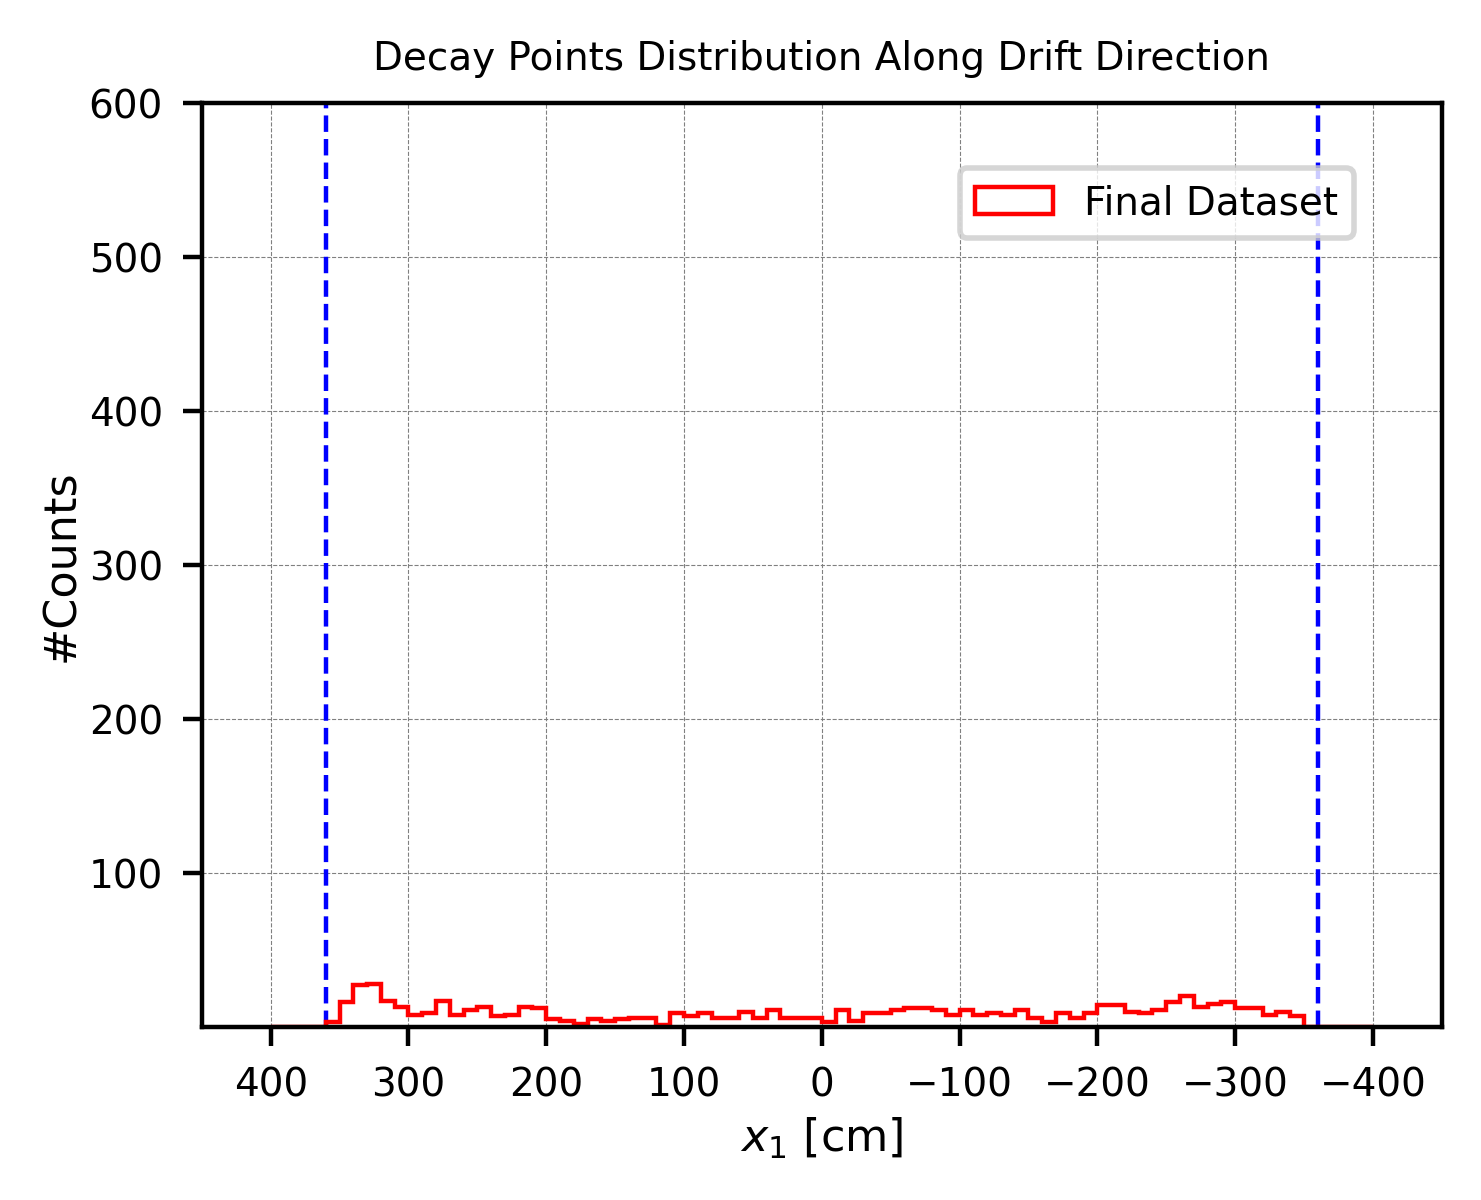

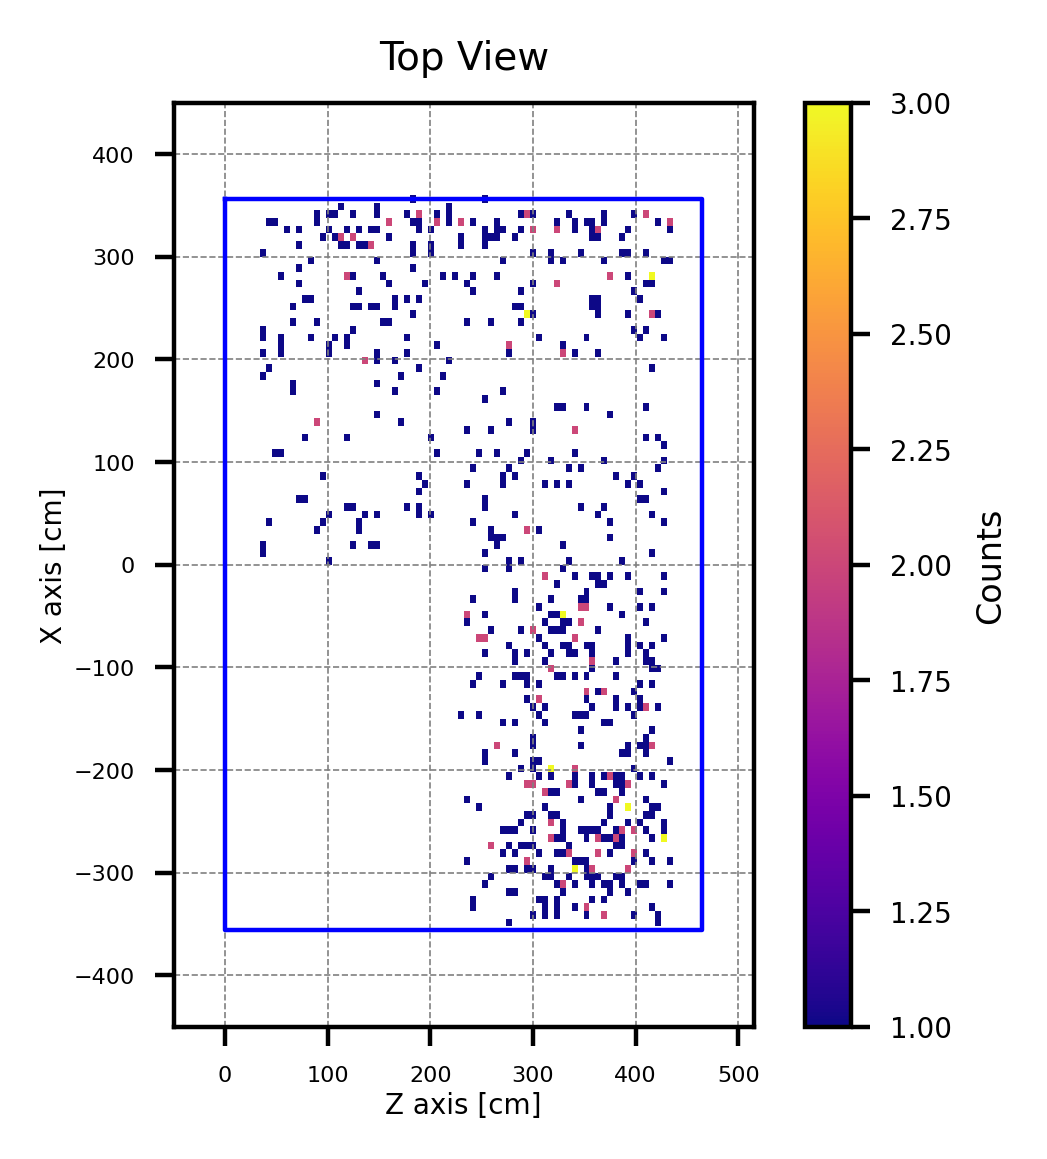

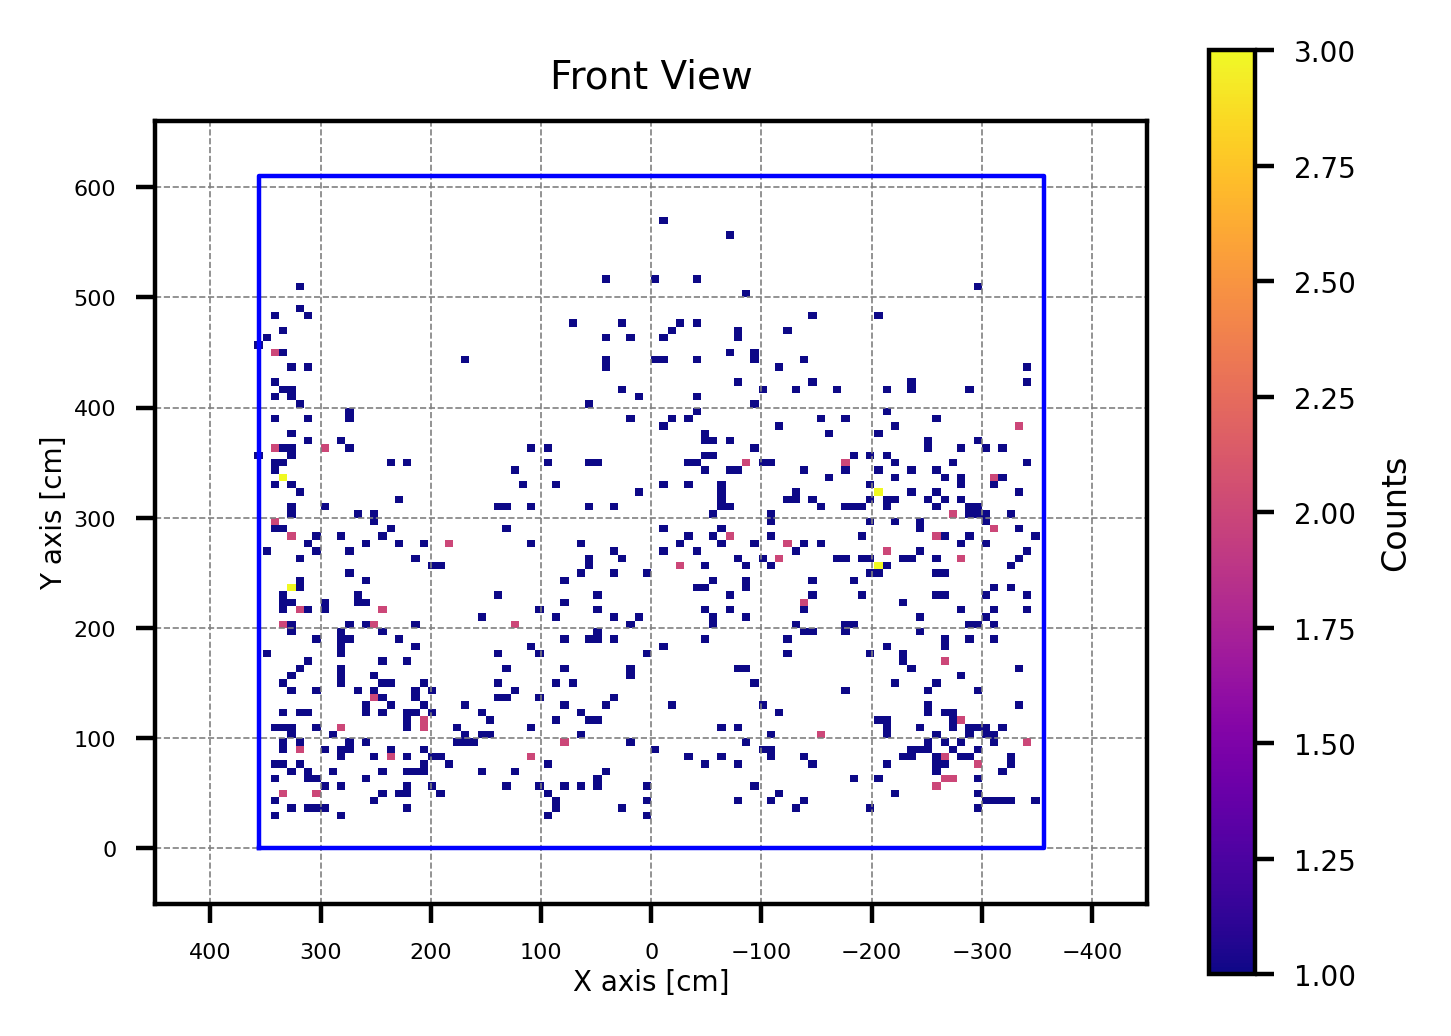

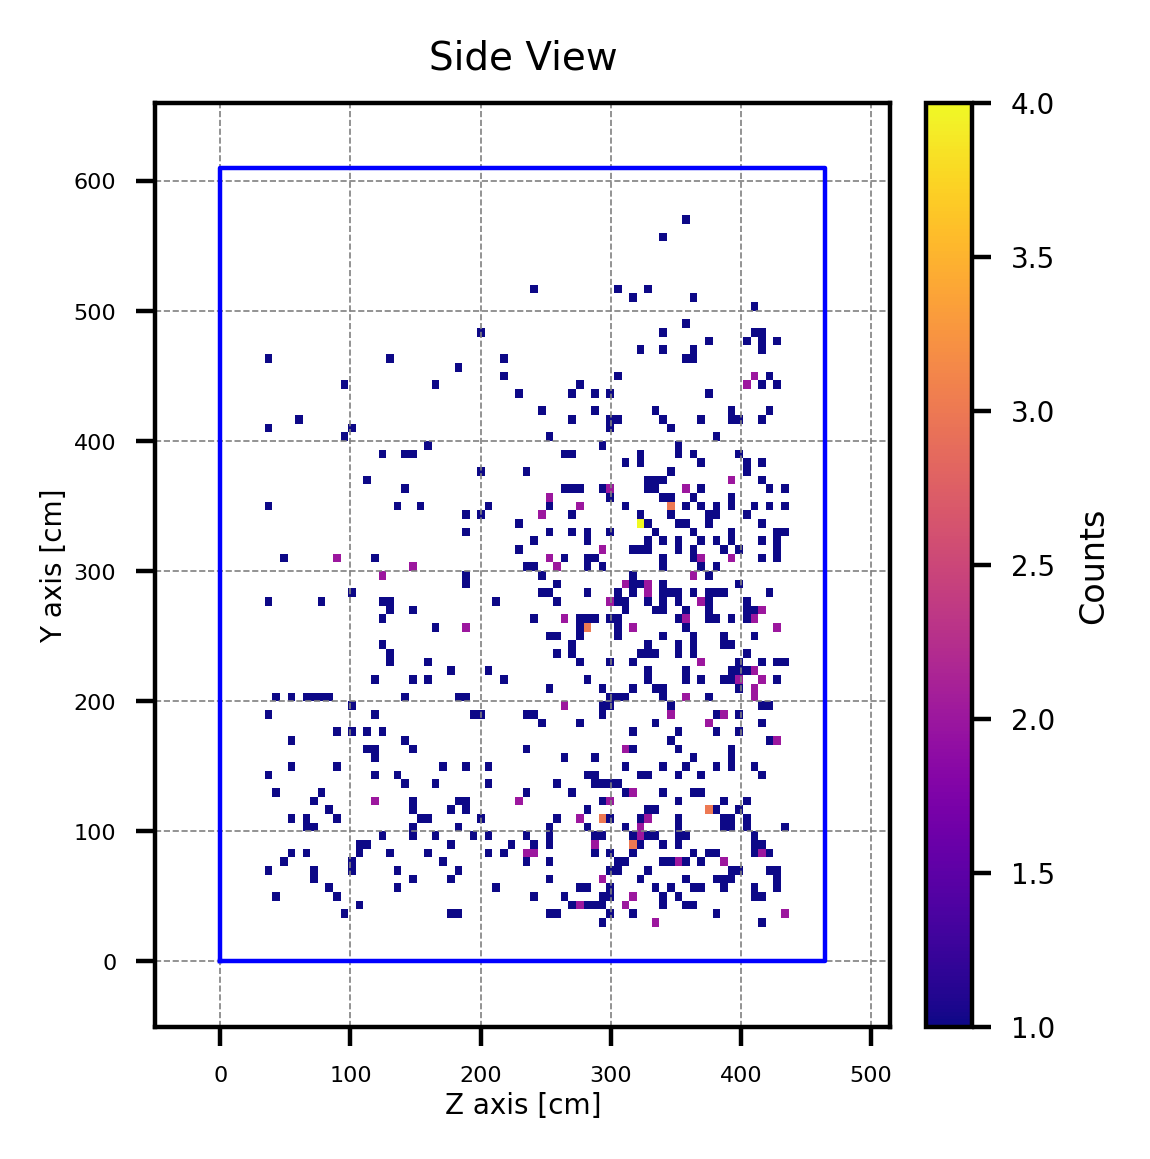

In [228]:
muon_time = [ev.posX for ev in events_reco_initial]

#"Reco" final events---
final_posX = [ev.posX for ev in events_newClass]
final_posY = [ev.posY for ev in events_newClass]
final_posZ = [ev.posZ for ev in events_newClass]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_final = np.array(final_posX)
neg_X = np.sum(decayX_final < 0)
pos_X = np.sum(decayX_final >= 0)
print("\n# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(decayX_final)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(decayX_final)*100))


# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(final_posX, bins=bins, range=(range_min, range_max), edgecolor='red', 
          histtype='step', linewidth=0.8, label="Final Dataset")

#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 600)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  







# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(final_posZ, final_posX, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(final_posX, final_posY, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(final_posZ, final_posY, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 



#### Detection Rate (PDS, on the basis of TPC cut)

Initial candidates (Space & MS & MH):  12757
Initial candidates && (APA2, 3, 4)  :  11358
FINAL candidates:  687 / 11358 (6.05%)

Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 | 0.000
   -345.0 | 0.206
   -335.0 | 0.385
   -325.0 | 0.258
   -315.0 | 0.462
   -305.0 | 0.429
   -295.0 | 0.471
   -285.0 | 0.455
   -275.0 | 0.325
   -265.0 | 0.408
   -255.0 | 0.421
   -245.0 | 0.212
   -235.0 | 0.173
   -225.0 | 0.172
   -215.0 | 0.206
   -205.0 | 0.157
   -195.0 | 0.080
   -185.0 | 0.063
   -175.0 | 0.076
   -165.0 | 0.024
   -155.0 | 0.039
   -145.0 | 0.059
   -135.0 | 0.036
   -125.0 | 0.042
   -115.0 | 0.030
   -105.0 | 0.038
    -95.0 | 0.024
    -85.0 | 0.030
    -75.0 | 0.025
    -65.0 | 0.025
    -55.0 | 0.019
    -45.0 | 0.014
    -35.0 | 0.013
    -25.0 | 0.005
    -15.0 | 0.012
     -5.0 | 0.008
      5.0 | 0.030
     15.0 | 0.015
     25.0 | 0.016
     35.0 | 0.038
     45.0 | 0.025
     55.0 | 0.054
     65.0 | 0.036
     75.0 | 0.037
     85.0 |

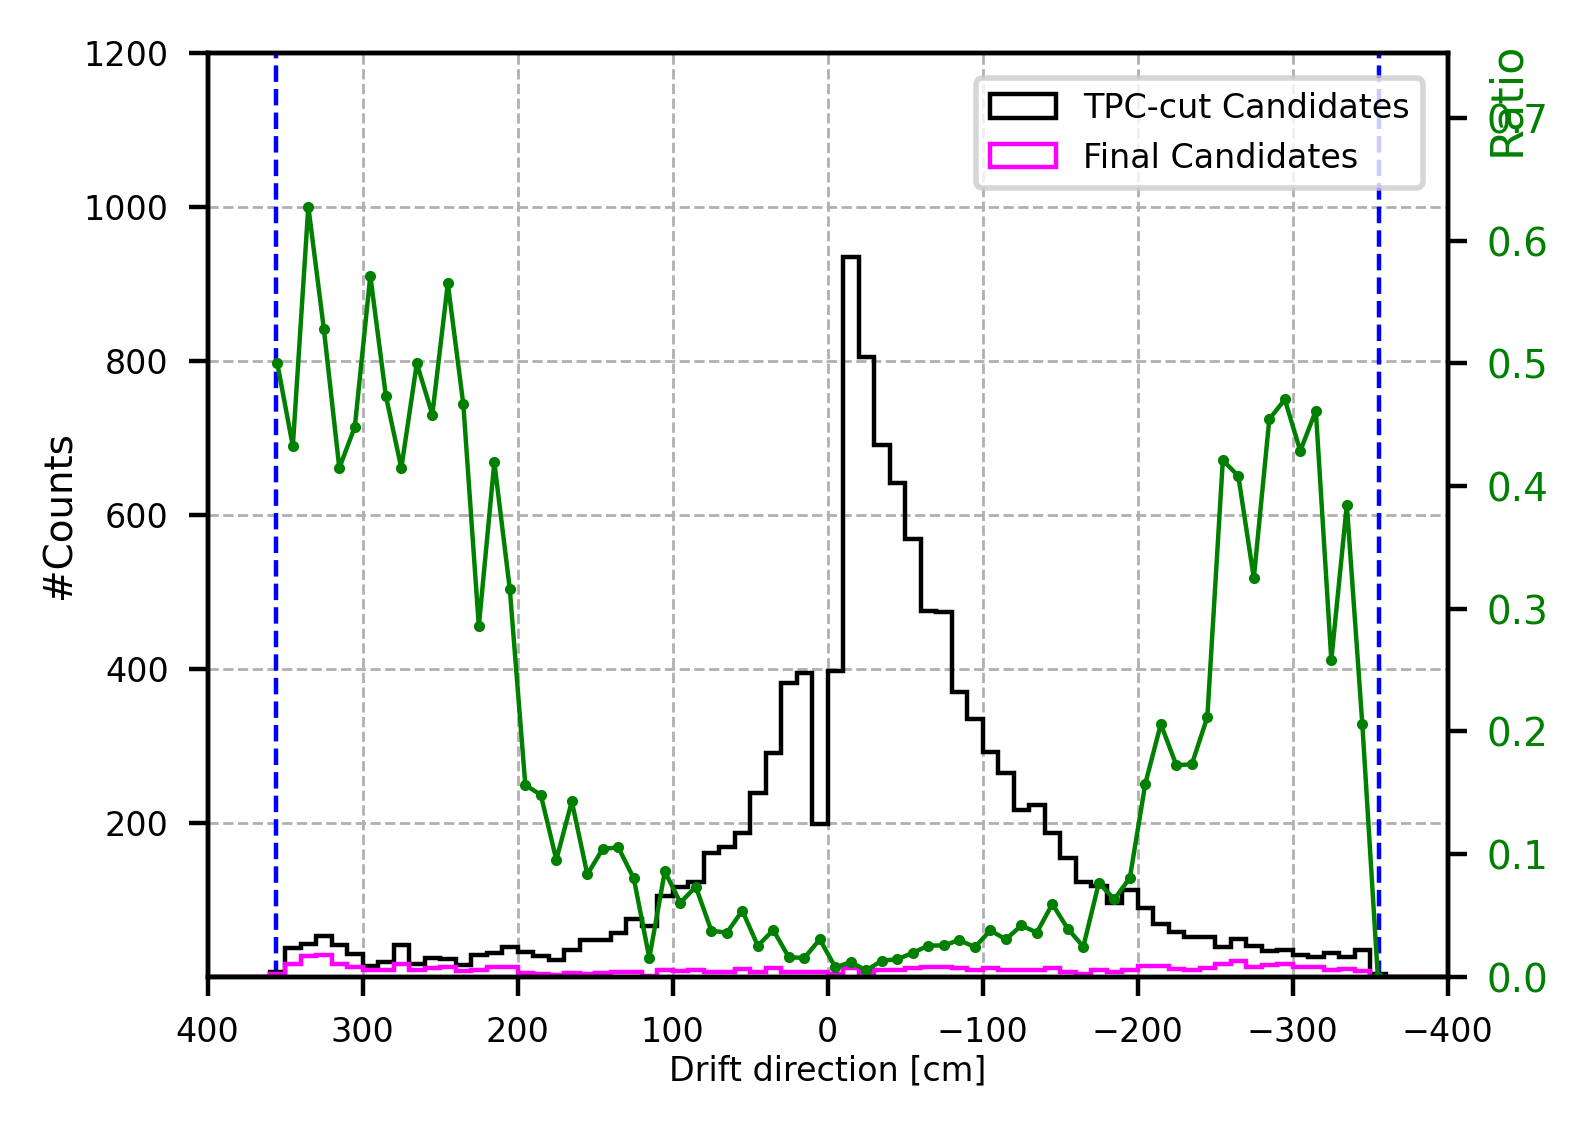

In [230]:
decayX_TPC = []#Candidates after TPC cut---
decayY_TPC = []
decayZ_TPC = []

with open('./statResult_20250920/decayX_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX_TPC.append(float(currentPlace))
with open('./statResult_20250920/decayY_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY_TPC.append(float(currentPlace))
with open('./statResult_20250920/decayZ_filtered.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ_TPC.append(float(currentPlace))

#Candidates only in apa2, 3 and 4---
decayX_TPC_apa234 = []
for i in range(0, len(decayX_TPC)):
    x = decayX_TPC[i]
    z = decayZ_TPC[i]
    if x > 0 or (x < 0 and z > 231.266):
        decayX_TPC_apa234.append(x)


print("Initial candidates (Space & MS & MH): ", len(decayX_TPC))
print("Initial candidates && (APA2, 3, 4)  : ", len(decayX_TPC_apa234))
print("FINAL candidates: ", len(final_posX), "/", len(decayX_TPC_apa234),  
      "({:.2f}%)".format(len(final_posX)/len(decayX_TPC_apa234)*100))




# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Histogram counts ---
n_initial, _ = np.histogram(decayX_TPC_apa234, bins=bins)
n_final, _ = np.histogram(final_posX, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio = []
ratio_centers = []

print("\nBin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial, n_final):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio.append(r)
        ratio_centers.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


# Filter out NaN values for min/max calculation
valid_ratios = [r for r in ratio if not np.isnan(r)]

if valid_ratios:
    print("\nMaximum ratio: {:.3f}".format(np.max(valid_ratios)))
    print("Minimum ratio: {:.3f}".format(np.min(valid_ratios)))
else:
    print("\nNo valid ratios to compute min/max.")


#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')


# Plot histograms
ax1.hist(bins[:-1], bins=bins, weights=n_initial, edgecolor='black',
         histtype='step', linewidth=0.8, label='TPC-cut Candidates')
ax1.hist(bins[:-1], bins=bins, weights=n_final, edgecolor='magenta',
         histtype='step', linewidth=0.8, label='Final Candidates')


ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-400, 400)
ax1.set_ylim(0.1, 1200)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
#ax1.set_yscale('log')
ax1.tick_params(labelsize=6)


# Secondary y-axis for ratio
ax2 = ax1.twinx()

ax2.plot(ratio_centers, ratio, 'o-', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=8, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.95)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)

plt.gca().invert_xaxis() 

# Final layout
#plt.tight_layout()
plt.show()
